# Chapter 5. Which branch Meera opens first

**Week 1, Monday. Chapter 5 of 6: is acquisition even the short branch, and which branch
does the 15 percent plan ask least of?**

**The need.** Meera has a tree with every branch measured. Marketing has proposed moving one
branch, customers, for Rs 12 crore. Before she signs she wants to know which branch to open
first, and why not the others.

| | |
|---|---|
| The metric at stake | Revenue growth against the 15 percent plan, and what each branch alone would have to do to reach it |
| Who asks | Meera; the marketing lead, who owns acquisition; the head of Retail-Plus, who owns the members most likely to come back |
| What a wrong number costs | Rs 12 crore placed on the branch that was fine, and a plan sized by adding lifts that multiply |
| A real company with the same question | Retailers pay to move frequency directly: Flipkart launched Flipkart Black at Rs 1,499 a year in 2025, evolving it from its VIP programme (Flipkart Stories, 12 September 2025), and Amazon offers Prime in India from Rs 399 to Rs 1,499 a year (About Amazon India). A membership is a bet on the frequency branch, placed by companies that could have spent the same money on acquisition. |

Chapter 4 settled the typical order at Rs 2,205, the median. The tree now reads 23 customers,
1.30 orders each, 16 of them bought once, and Rs 5,44,810 booked on 30 orders.

> **Kavya's review.** Pick the branch the evidence points at and the one that costs least to
> test. Then say what would make you pick another.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

ORDERS = kit.load_records()

for order in ORDERS:
    order["amount"] = int(order["amount"])
revenue = sum(o["amount"] for o in ORDERS)
counts = {}
for order in ORDERS:
    counts[order["customer_id"]] = counts.get(order["customer_id"], 0) + 1
customers, orders = len(counts), len(ORDERS)
per_customer, aov = orders / customers, revenue / orders
once = sum(1 for c in counts.values() if c == 1)
print(f"{customers} customers x {per_customer:.2f} orders x {kit.rupees(aov)} = {kit.rupees(customers * per_customer * aov)}")

23 customers x 1.30 orders x Rs 18,160 = Rs 5,44,810


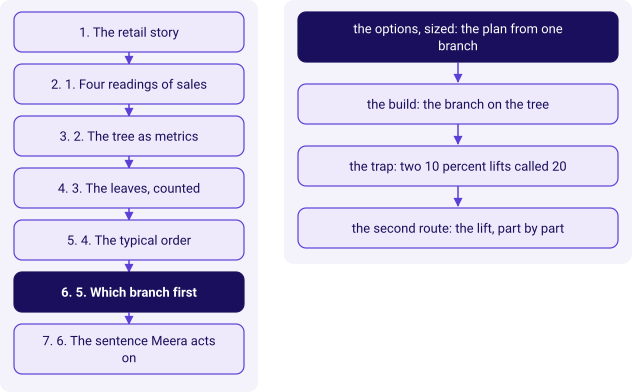

In [2]:
kit.side_by_side(
    kit.ladder(['The retail story', '1. Four readings of sales', '2. The tree as metrics', '3. The leaves, counted', '4. The typical order', '5. Which branch first', '6. The sentence Meera acts on'], lit=5, show=False),
    kit.vflow(['the options, sized: the plan from one branch', 'the build: the branch on the tree', 'the trap: two 10 percent lifts called 20', 'the second route: the lift, part by part'], lit=0, show=False),
)

## The options

The plan is 15 percent on booked revenue: Rs 81,722 more on this extract. Each branch could
carry it alone, and each asks something different. The sizing cell computes what.

**Predict before you run.** Which branch asks for the fewest new actions from customers?

- a) Customers: about 3.45 more customers who buy like today's.
- b) Price: every price up 15 percent with nobody leaving.
- c) Order value: Rs 2,724 more on every order.
- d) Frequency: about 4.5 more orders from the 23 customers already on file.

option: the branch moved alone,this quarter,the plan needs,in plain words,evidence in this file
"A. acquisition, customers",23,26.45,3.45 more customers who buy like today's,none: one window cannot show customers falling
"B. frequency, orders per customer",1.30,1.50,"4.5 more orders from the same 23, about 5 of the 16 one-time buyers returning once",7 of 23 already came back
C. order value,"Rs 18,160","Rs 20,884","Rs 2,724 more per order, on an average one order drags",items and prices are not in this file
D. price,today's prices,15 percent higher,every price up with nobody leaving,none; and nothing sells above MRP


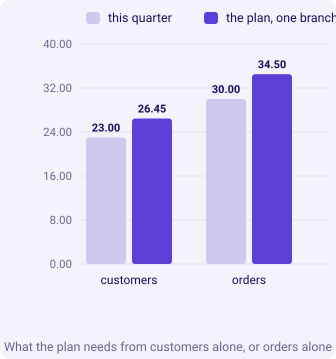

In [3]:
plan = revenue * 1.15
need = {"customers": customers * 1.15, "orders": orders * 1.15, "aov": aov * 1.15}
kit.table(["option: the branch moved alone", "this quarter", "the plan needs", "in plain words", "evidence in this file"],
          [("A. acquisition, customers", customers, f"{need['customers']:.2f}",
            f"{need['customers'] - customers:.2f} more customers who buy like today's", "none: one window cannot show customers falling"),
           ("B. frequency, orders per customer", f"{per_customer:.2f}", f"{need['orders'] / customers:.2f}",
            f"{need['orders'] - orders:.1f} more orders from the same {customers}, about 5 of the {once} one-time buyers returning once",
            "7 of 23 already came back"),
           ("C. order value", kit.rupees(aov), kit.rupees(need["aov"]),
            f"{kit.rupees(need['aov'] - aov)} more per order, on an average one order drags", "items and prices are not in this file"),
           ("D. price", "today's prices", "15 percent higher", "every price up with nobody leaving", "none; and nothing sells above MRP")],
          caption=f"The 15 percent plan is {kit.rupees(plan)} of booked revenue")
kit.columns(["customers", "orders"], [("this quarter", [customers, orders]),
                                      ("the plan, one branch alone", [need["customers"], need["orders"]])],
            fmt=lambda v: f"{v:.2f}", title="What the plan needs from customers alone, or orders alone")
kit.check("customers alone reach the plan through the tree",
          abs(need["customers"] * per_customer * aov - plan) < 1)
kit.check("orders alone reach the plan through the tree", abs(need["orders"] * aov - plan) < 1)

**What happened.** Both a and d are small asks in customers' actions; the difference is who
is asked. Acquisition has to find 3.45 people Kalpa has never met; frequency asks 5 of the 16
who already bought once to come back once, and 7 others already did. Price and order value
rest on fields this file does not hold, or on an average one order drags.

**The best-fit call.** B, frequency first: the customers exist, the file shows some of them
return, and a retention test costs a reminder or an offer to people already on the list,
where acquisition pays marketing to find new ones. **What would change it:** Tuesday's second
quarter showing customers falling while frequency held, or a cost per retained order above the
cost of acquiring a customer; either moves the call to A.

## 1. The build: the branch on the tree

**Predict before you run.** How many of the 23 customers bought exactly once?

- a) 7.
- b) 23.
- c) 16.
- d) 0.

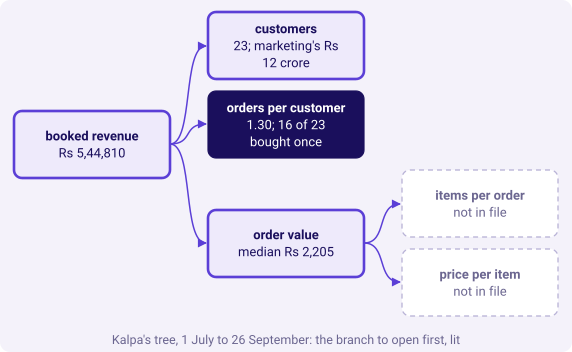

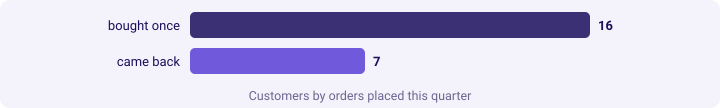

In [4]:
kit.driver_tree({"label": "booked revenue", "note": kit.rupees(revenue), "kind": "known", "children": [
    {"label": "customers", "note": f"{customers}; marketing's Rs 12 crore", "kind": "known"},
    {"label": "orders per customer", "note": f"{per_customer:.2f}; {once} of {customers} bought once", "kind": "lit"},
    {"label": "order value", "note": "median Rs 2,205", "kind": "known", "children": [
        {"label": "items per order", "note": "not in file", "kind": "unknown"},
        {"label": "price per item", "note": "not in file", "kind": "unknown"}]}]},
    title="Kalpa's tree, 1 July to 26 September: the branch to open first, lit")
kit.bars([("bought once", once), ("came back", customers - once)], lit=(0,),
         title="Customers by orders placed this quarter")
kit.check("16 of 23 customers bought once", once == 16)
kit.check("every customer is either once or came back", once + (customers - once) == 23)

**What happened.** The answer is c. Sixteen customers are one order away from moving the
frequency branch, which is the branch Meera opens first.

## 2. The trap: two 10 percent lifts called 20 percent

The marketing lead answers the frequency case with a bigger plan: "Fund acquisition and a
retention programme together. A 10 percent lift in customers and a 10 percent lift in orders
per customer make 20 percent growth, well over the 15 percent plan."

**Predict before you run.** What do the two lifts really make?

- a) 20 percent, as the slide says.
- b) 21 percent.
- c) 10 percent, since the lifts overlap.
- d) 11 percent.

**The plausible wrong answer.**

In [5]:
added = revenue * (1 + 0.10 + 0.10)
print(f"Revenue after both lifts: {kit.rupees(added)}, growth 20 percent")

Revenue after both lifts: Rs 6,53,772, growth 20 percent


**Why it is wrong.** The branches multiply, so the lifts multiply: the second lift applies to a
customer base that is already 10 percent larger. Adding them drops the lift on the lift, and at
bigger or more numerous lifts the gap grows until a budget sized by addition misses its target.
The check recomputes revenue leaf by leaf through the tree.

through the tree: Rs 6,59,220, growth 21%; the slide's figure Rs 6,53,772, short by Rs 5,448


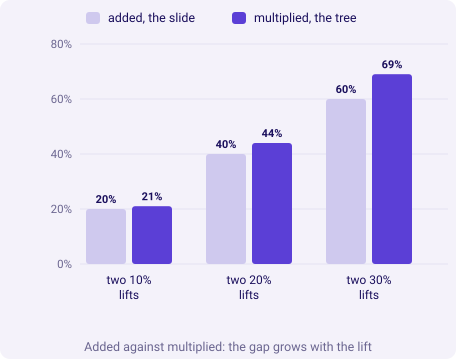

In [6]:
through_tree = (customers * 1.10) * (per_customer * 1.10) * aov
print(f"through the tree: {kit.rupees(through_tree)}, growth {through_tree / revenue - 1:.0%}; "
      f"the slide's figure {kit.rupees(added)}, short by {kit.rupees(through_tree - added)}")
lifts = [0.10, 0.20, 0.30]
kit.columns([f"two {int(l * 100)}% lifts" for l in lifts],
            [("added, the slide", [2 * l * 100 for l in lifts]),
             ("multiplied, the tree", [((1 + l) ** 2 - 1) * 100 for l in lifts])],
            fmt=lambda v: f"{v:.0f}%", title="Added against multiplied: the gap grows with the lift")
kit.check("through the tree, two 10 percent lifts make 21 percent", round(through_tree / revenue - 1, 2) == 0.21)
kit.check("the added figure is Rs 6,53,772", round(added) == 653772)
kit.check("the tree's figure is Rs 6,59,220", round(through_tree) == 659220)

**The fix, and what changed.** The answer is b: Rs 6,59,220, 21 percent, Rs 5,448 above the
slide. At 10 percent the gap is small; two 30 percent lifts make 69 percent where the slide
would say 60. The same rule prices a discount: 15 percent off with 10 percent more orders is
0.85 x 1.10 = 0.935, a 6.5 percent fall that addition would call a 5 percent fall.

> **Kavya's review.** Recompute through the tree anything someone adds up. Then tell Meera the
> branch the evidence points at, frequency, and that the lifts multiply whichever she funds.

## A second route: the lift, part by part

Revenue after both lifts is the base, plus the customer lift, plus the frequency lift, plus the
lift on the lift, 1 percent of the base. A bridge built from those four parts must land where
the multiplication did.

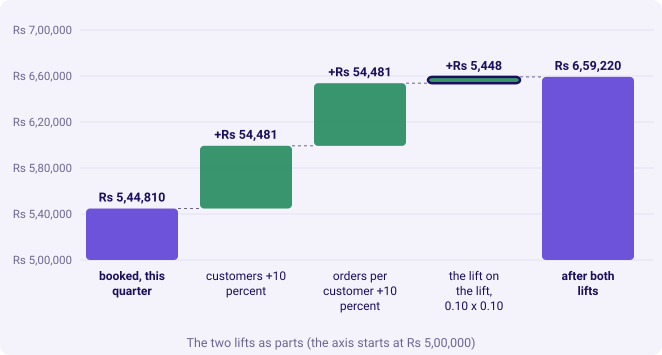

In [7]:
parts = [("customers +10 percent", revenue * 0.10), ("orders per customer +10 percent", revenue * 0.10),
         ("the lift on the lift, 0.10 x 0.10", revenue * 0.01)]
kit.bridge(("booked, this quarter", revenue), [(n, round(v)) for n, v in parts],
           end_label="after both lifts", lit=(2,), lo=500000,
           title="The two lifts as parts (the axis starts at Rs 5,00,000)")
kit.check("the parts land on the multiplied total", abs(revenue + sum(v for _, v in parts) - through_tree) < 1e-6)

**When to switch.** Multiply the factors when you need the total; build the parts when someone
asks where the extra came from, since the bridge shows the lift on the lift as its own bar. The
parts route is the one that wins the argument with the slide.

### In the interview

**[D] Marketing wants budget for acquisition; what would you check before agreeing it is the
right branch, and how would you say no?** "I would count customers by id and see how many came
back, value a first order at the median rather than the mean, and ask for the quarter before
this one to see whether customers actually fell. On Kalpa's quarter 16 of 23 bought once and 7
came back, and the typical order is Rs 2,205 against a Rs 18,160 mean. The no is a no for now
with a date: frequency is the cheaper branch to test, and if Tuesday's two quarters show
customers fell, acquisition goes first."

**[F] A 10 percent lift in customers and a 10 percent lift in frequency make 20 percent growth;
what is the right number, and when does it matter?** "21 percent, because branches multiply:
1.10 x 1.10 = 1.21. It matters when the lifts are large or many; two 30 percent lifts make 69,
not 60, and a target sized by addition is missed by the difference."

**[D] Which of four branches would you open first for a retailer, and what would make you
switch?** "The one the evidence says is short and that costs least to test. Here frequency: the
customers exist and a third already came back. I would switch to acquisition if a second window
showed customers falling with frequency steady, or if retaining an order cost more than
acquiring a customer."

### Depth: how far a discount has to lift orders to break even

A 15 percent discount needs orders up 1 / 0.85 less one, about 17.6 percent, just to hold
revenue, and more to hold margin.

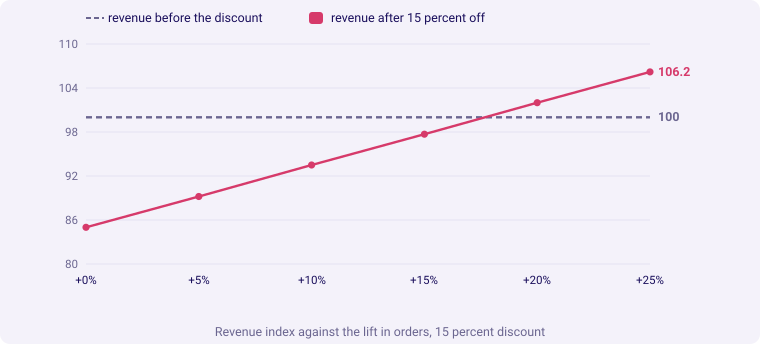

In [8]:
lift_axis = [0, 5, 10, 15, 20, 25]
kit.line([f"+{l}%" for l in lift_axis],
         [("revenue before the discount", [100] * 6, "plan"),
          ("revenue after 15 percent off", [round(85 * (1 + l / 100), 1) for l in lift_axis], "bad")],
         fmt=lambda v: f"{v:g}", lo=80, title="Revenue index against the lift in orders, 15 percent discount")
kit.check("the break-even lift is about 17.6 percent", round((1 / 0.85 - 1) * 100, 1) == 17.6)

## What this chapter established

In [9]:
kit.table(["What we now know", "The evidence"],
          [("The plan asks little of either customer branch", "3.45 more customers, or 4.5 more orders"),
           ("Frequency is the branch to open first", f"{once} of {customers} bought once; 7 came back"),
           ("Lifts multiply", "two 10 percent lifts make 21 percent, Rs 6,59,220")],
          caption="Chapter 5: which branch first")
kit.check_summary()
print("Next: chapter 6 writes the sentence Meera can act on, and its caveat.")

What we now know,The evidence
The plan asks little of either customer branch,"3.45 more customers, or 4.5 more orders"
Frequency is the branch to open first,16 of 23 bought once; 7 came back
Lifts multiply,"two 10 percent lifts make 21 percent, Rs 6,59,220"


Next: chapter 6 writes the sentence Meera can act on, and its caveat.
